# Process an image
## Overview

In this notebook we will perform a typical image-analysis workflow of DVP data. This involves 

1. cell segmentation based on an _unspecific_ **cytosolic** and **nuclear** stain
2. feature extraction (channel intensity values, area)
3. quality control of the segmentation results based on cell area and feature intensities.
3. cell classification based on thresholding of a **marker channel**, i.e. an immunofluorescence stain that marks a functionally distinct cell population. 
4. contour processing and export for laser microdissection.

Here, we will leverage the _spatialdata_ framework as a data container that stores images, cell segmentation masks (_labels_), shape contours/vectors (_shapes_) in a single unified object. The data format makes  workflows build on it highly modular and scalable. We will use the package `harpy`, which interfaces with spatialdata, for the image analysis: Cell segmentation with Cellpose-SAM, and extraction of the channel intensities. The classification of cells in marker-positive and marker-negative cells is performed by thresholding the channel intensities. Finally, marker-positive cells are exported to a LMD7-compatible xml file with pyLMD 


> Note that we do not explain the syntax of the code in this notebook. For usage-specific questions, we refer the users to the excellent documentation of the respective packages.

## Dataset

In this example, we will analyse a melanoma sample. The specimen was stained with 3 stains:

| Index | Channel | Marker | Specificity |
| --- | --- | --- | --- | 
| 0 |  AF647 | Sox10 | Melanocytes and Melanoma cells | 
| 1 | AF488 | Nucleus | Cell nuclei |
| 2 | AF568 | Cell membrane marker | |

We will use the unspecific stains to segment all cells and the marker channel for cell classification. 


## References

^[Spatialdata: Marconato, L. et al. SpatialData: an open and universal data framework for spatial omics. Nat Methods 1–5 (2024) doi:10.1038/s41592-024-02212-x.]

^[Harpy: Rombaut, B. et al. Scalable analysis of whole slide spatial proteomics with Harpy. Bioinformatics btag122 (2026) doi:10.1093/bioinformatics/btag122.]

^[Cellpose-SAM: Pachitariu, M., Rariden, M. & Stringer, C. Cellpose-SAM: superhuman generalization for cellular segmentation. 2025.04.28.651001 Preprint at https://doi.org/10.1101/2025.04.28.651001 (2025).]

^[pyLMD: Schmacke, N. A. et al. SPARCS, a platform for genome-scale CRISPR screening for spatial cellular phenotypes. Preprint at https://doi.org/10.1101/2023.06.01.542416 (2023).]

## Import

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import harpy
import lmd.lib as pylmd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely
import spatialdata as sd
import spatialdata_plot  # noqa
from dask.distributed import Client
from napari_spatialdata import Interactive
from spatialdata_io.readers.generic import image as spatialdata_imread

Accelerate the notebook run by setting `SUBSET_SDATA = True` (only runs notebook on a 15000 px x 15000 px subset)

In [2]:
SUBSET_SDATA = True

## Functions

In [3]:
def random_sample_by_area(
    gdf: gpd.GeoDataFrame,
    target_area: float,
    exclusion_distance: float | None,
    random_state: int = 42,
):
    """Randomly select shapes from a geopandas dataframe up to a specified area.

    Parameters
    ----------
    gdf
        Shapes to select from
    target_area
        Target area in the units of the shape dataframe (typically square pixels).
    exclusion_distance
        Minimal distance between two adjacent shapes in order to select them in units of the shape dataframe (px).
        Any point of the next shape is guaranteed to have at least `exclusion_distance` from any point in all previous shapes.
        If None, allows for overlapping shapes
    random_state
        Random state to reproducibly select shapes

    Raises
    ------
    warning
        If target area is not reached
    """
    np.random.seed(random_state)
    random_indices = np.random.permutation(len(gdf))

    total_area = 0
    selected_cells = []
    for idx in random_indices:
        row = gdf.iloc[idx]

        # Skip if cells are too close to one another
        if exclusion_distance is not None:
            if any(
                shapely.dwithin(row.geometry, ref.geometry, distance=exclusion_distance)
                for ref in selected_cells
            ):
                continue

        selected_cells.append(row)
        total_area += row.geometry.area

        # Stop if target area is reached
        if total_area > target_area:
            break

    selected_cells = gpd.GeoDataFrame(
        pd.concat(selected_cells, axis=1).T, geometry=gdf.geometry.name
    )

    if selected_cells.geometry.area.sum() < target_area:
        warnings.warn(
            f"Target area was {target_area}, only identified cells with total area of {selected_cells.geometry.area.sum()}"
        )
    return sd.models.ShapesModel.parse(selected_cells)


def largest_polygon_from_multipolygon(geom):
    """Return largest geom from a multipolygon."""
    if not isinstance(geom, (shapely.Polygon, shapely.MultiPolygon)):
        raise ValueError(f"Must be polygon or multipolygon, not {type(geom)}")
    if isinstance(geom, shapely.Polygon):
        return geom

    idx_max = np.argmax([g.area for g in geom.geoms])
    warnings.warn(f"Select {idx_max} for geom")

    return geom.geoms[idx_max]

## Parameters

Here, we define parameters that help us to run the notebook

In [4]:
# This value can be inspected in the microscope or extracted from the raw microscopy file
IMAGE_RESOLUTION = 0.1725  # microns per pixel

image_name = "2025_02_19_wholeTissue_melanomaAb_01-Scene-2-ScanRegion1big_c1-3"
image_path = Path(f"../../data/{image_name}.tiff")
results_path = Path("../../results")

# Channels
marker_channel = "0"
nucleus_channel = "1"
cytosol_channel = "2"

# Cell segmentation
expected_cell_diameter = 50

## Data ingestion/Create spatialdata

We can create a spatialdata object from the provided `tiff` images with the [`spatialdata-io`](https://spatialdata.scverse.org/projects/io/en/latest/) image reader function. For image formats that are not supported by `spatialdata-io`, users can either achieve similar behavior with generic image readers (like `dask.array.image.imread`), or [`dvp-io`](https://dvp-io.readthedocs.io/en/latest/) for vendor-specific microscopy formats.

In [5]:
image = spatialdata_imread(
    image_path,
    data_axes=("x", "y", "c"),
    coordinate_system="global",
    use_tiff_memmap=False,
)
sdata = sd.SpatialData(images={"image": image})

In [6]:
# Write to disk to execute task graph (speeds up downstream workflow if data is loaded lazily)
if SUBSET_SDATA:
    sdata = sdata.query.bounding_box(
        axes=("y", "x"),
        min_coordinate=[40000, 5000],
        max_coordinate=[55000, 20000],
        target_coordinate_system="global",
    )

sdata.write(results_path / f"{image_name}.sdata.zarr")

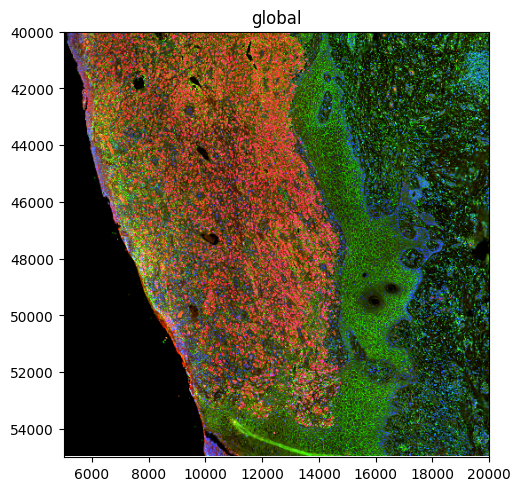

In [7]:
# Read the data from disk and plot the spatialdata object
sdata = sd.read_zarr(results_path / f"{image_name}.sdata.zarr")
sdata.pl.render_images().pl.show()

## Segmentation
The cell segmentation step generates segmentation masks which will later be used for the dissection.

### Implementation
We run cell segmentation with Cellpose-SAM. In this notebook, we leverage `harpy.im.segment` to execute the cell segmentation run in a tilewise fashion. This function provides a way to perform chunkwise image segmentation of overlapping tiles with conflict resolution for overlapping cells. This functionality is critical as whole slide images often exceed the memory of typical compute setups. Comparable functionalities to `harpy.im.segment` are also implemented python packages like [`sopa`](https://gustaveroussy.github.io/sopa/), [`scportrait`](https://mannlabs.github.io/scPortrait/index.html), and [`spatialproteomics`](https://sagar87.github.io/spatialproteomics/) packages.

The downstream shape-export step requires _vectorized_ shapes (i.e shapes that are defined by a list of coordinates), while segmentation models typically return _segmentation masks_ (i.e. raster data). Harpy will directly provide the shapes when passing the `output_shapes_layer` parameter.

In [8]:
cellpose_kwargs = {
    # Additional keyword arguments passed to the provided model
    "channels": None,  # cellpose 4 uses the first 3 channels
    "normalize": True,  # normalize images by clipping
    "diameter": expected_cell_diameter,  # Diameter is an important parameter for cellpose 3
    "flow_threshold": 0.4,  # default settings
    "cellprob_threshold": 0,  # default settings
    "pretrained_model": "cpsam",
}

In [ ]:
# Runs ca. 30 min on a MacBook Pro (M3)
# We start a dask.distributed.Client. This enables us to follow the tasks and how their are executed in a dashboard
# Click on the dashboard link to view the dask dashboard in a webbrowser.
with Client() as client:
    print(f"Open dashboard at {client.dashboard_link}")

    # Perform segmentation with a vanilla cellpose model
    _ = harpy.im.segment(
        sdata=sdata,
        img_layer="image",
        model=harpy.im.cellpose_callable,
        output_labels_layer="segmentation_mask",
        output_shapes_layer="segmentation_boundaries",
        **cellpose_kwargs,
        device=None,  # autodetect device
    )

Open dashboard at http://127.0.0.1:8787/status


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated

### Cell Segmentation Evaluation (Critical step)

The segmentation results are critical for successful dissection. We highly recommend to visually inspect the segmentation results. If the results are not satisfactory, users may train a custom cellpose model or try alternative segmentation methods. 

2026-07-21 09:41:12.399 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


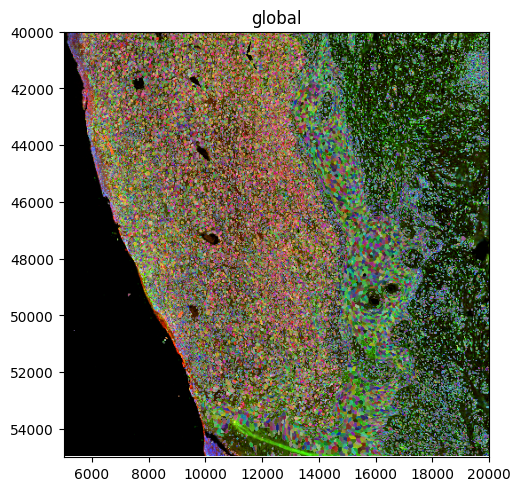

In [10]:
# Interactively in napari
session = Interactive(sdata)
session.run()

# Statically with spatialdata-plot
sdata.pl.render_images("image").pl.render_labels("segmentation_mask").pl.show()

### Extract features

Next, we extract _features_ for the segmented cells. Typically, we are interested in channel intensities, and shape properties (like area, ellipticity, etc.). Here, we use the respective functions in harpy to extract channel intensities and shape properties from the cell segmentation masks. 

In [11]:
# Channel intensities
_ = harpy.tb.allocate_intensity(
    sdata,
    img_layer="image",
    labels_layer="segmentation_mask",
    output_layer="segmentation_features",
    mode="sum",
)

# Shape properties
_ = harpy.tb.add_regionprops(
    sdata,
    labels_layer="segmentation_mask",
    table_layer="segmentation_features",
    output_layer="segmentation_features",
    overwrite=True,
)

/Users/lucas-diedrich/mamba/envs/npdvp/lib/python3.13/site-packages/harpy/table/_allocation_intensity.py:338: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  adata.obsm[spatial_key] = coordinates
/Users/lucas-diedrich/mamba/envs/npdvp/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'segmentation_mask', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/lucas-diedrich/mamba/envs/npdvp/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
2026-07-21 09:42:29.607 | WARNING  | harpy.utils._io:_incremental_io_on_disk:78 - layer with name 'segmentation_features' already exists. Overwriting...


### Preprocess

Here, we normalize the summed channel intensities by their area (in pixels) to make them independent of cell size. 

In [12]:
# Extract channel names
channels = sdata["segmentation_features"].var_names

# Assign to adata.obs for simpler interaction
sdata["segmentation_features"].obs[[f"{channel}_intensity" for channel in channels]] = (
    sdata["segmentation_features"].X
)

# Area normalize
for channel in channels:
    sdata["segmentation_features"].obs[f"{channel}_intensity__area_normalized"] = (
        sdata["segmentation_features"].obs[f"{channel}_intensity"]
        / sdata["segmentation_features"].obs["area"]
    )

## Quality Control

The quality control (**QC**) step aims to remove segmentation- and staining artifacts. 

**Segmentation artifacts** are typically marked by abnormally formed or sized shapes that do not correspond to actual cells in the image. This may include very small segmentation spots, large segmented blobs, or incorrectly formed shapes. These artifacts can typically be removed with area-based filters. Segmentation artifacts outside of the tissue can often be removed by thresholding based on the nucleus channel or other unspecific stains.

Staining artifacts may represent spots with extremely high staining intensities, that often occur due to unspecific staining or antibody aggregation. They can be removed via thresholding in the respective channel. 

We typically plot the distribution of the QC-features and then decide on suitable thresholds based on these diagnostic plots.

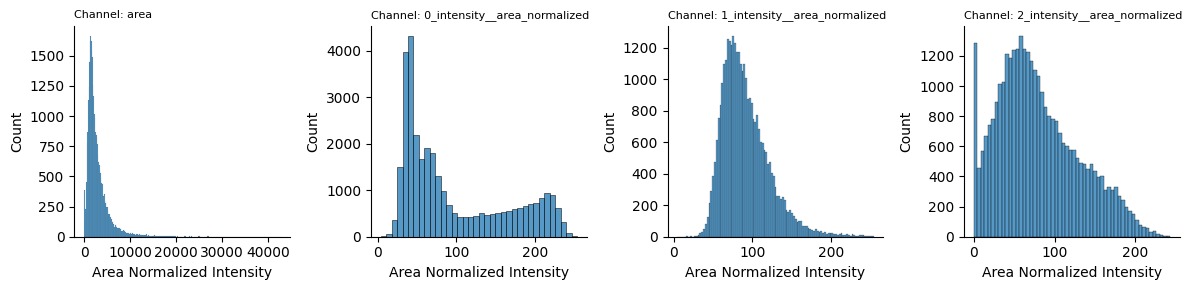

In [13]:
features = ["area", *(f"{channel}_intensity__area_normalized" for channel in channels)]

fig, axs = plt.subplots(1, len(features), figsize=(3 * len(features), 3), squeeze=False)
for feature, ax in zip(features, axs.ravel(), strict=True):
    sns.histplot(data=sdata["segmentation_features"].obs, x=feature, ax=ax)
    ax.set_title(f"Channel: {feature}", loc="left", fontsize=8)
    ax.set_xlabel("Area Normalized Intensity")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

For unspecifically binding markers, we typically remove lower and upper outliers: Lower outliers might represent segmentation artifacts outside of the tissue, while upper outliers represent staining artifacts. For specific marker channels, we expect true-negative cells and thus only remove upper outliers.

Here we select the following area thresholds and channel-intensity thresholds **which should be adjusted based on the specific dataset at hand**:

In [14]:
# !!! adjust based on dataset
min_area_threshold = 200
max_area_threshold = 20000

min_quantile_unspecific_channel = 0.01
max_quantile_unspecific_channel = 0.99

max_quantile_marker_channel = 0.99

In [15]:
# Apply filters

area_outlier = (sdata["segmentation_features"].obs["area"] < min_area_threshold) | (
    sdata["segmentation_features"].obs["area"] > max_area_threshold
)

cytosol_channel_intensities = sdata["segmentation_features"].obs[
    f"{cytosol_channel}_intensity__area_normalized"
]
cytosol_channel_outlier = (
    cytosol_channel_intensities
    < np.quantile(cytosol_channel_intensities, min_quantile_unspecific_channel)
) | (
    cytosol_channel_intensities
    > np.quantile(cytosol_channel_intensities, max_quantile_unspecific_channel)
)

nucleus_channel_intensities = sdata["segmentation_features"].obs[
    f"{nucleus_channel}_intensity__area_normalized"
]
nucleus_channel_outlier = (
    nucleus_channel_intensities
    < np.quantile(nucleus_channel_intensities, min_quantile_unspecific_channel)
) | (
    nucleus_channel_intensities
    > np.quantile(nucleus_channel_intensities, max_quantile_unspecific_channel)
)

marker_channel_intensities = sdata["segmentation_features"].obs[
    f"{marker_channel}_intensity__area_normalized"
]
marker_channel_outlier = marker_channel_intensities > np.quantile(
    marker_channel_intensities, max_quantile_marker_channel
)

# Define outliers based on `logical OR` of all metrics
sdata["segmentation_features"].obs["segmentation_outlier"] = (
    area_outlier
    | cytosol_channel_outlier
    | nucleus_channel_outlier
    | marker_channel_outlier
)

### Visualization

Here, we visualize the outlier assignment on the tissue. 

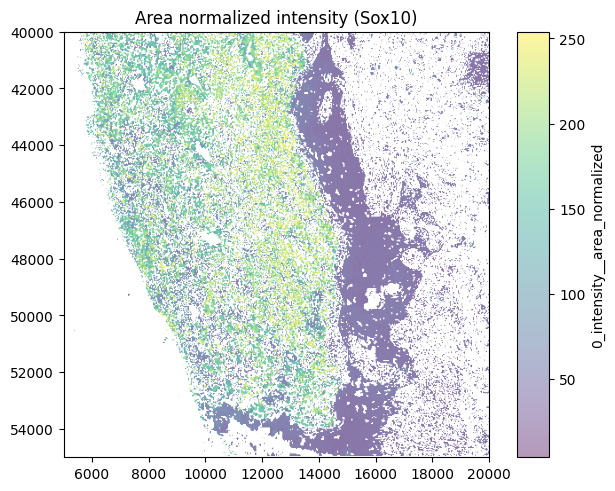

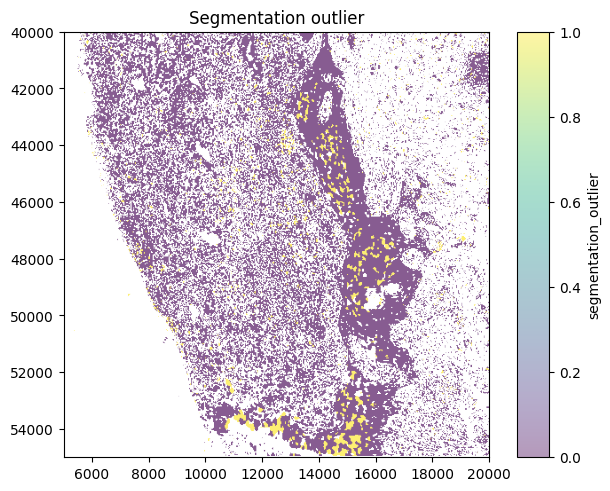

In [16]:
(
    sdata
    # .pl.render_images("image")
    .pl.render_labels(
        "segmentation_mask", color=f"{marker_channel}_intensity__area_normalized"
    ).pl.show(title="Area normalized intensity (Sox10)")
)

(
    sdata
    # .pl.render_images("image")
    .pl.render_labels("segmentation_mask", color="segmentation_outlier").pl.show(
        title="Segmentation outlier"
    )
)

## Classification

Classification into functional subsets is performed based on the specific marker channels. Here, we use simple thresholding to identify melanoma cells based on SOX10 expression. More sophisticated classification models (e.g. Random Forest, Deep Learning-based classification) have  also been used previously but rely on the manual annotation of a subset of cells and subsequent model training. 

### Threshold

In [17]:
marker_intensity_cutoff = 100

Here we plot the distribution of the marker channel intensity and the decision boundary for the classification into positive/negative cells 

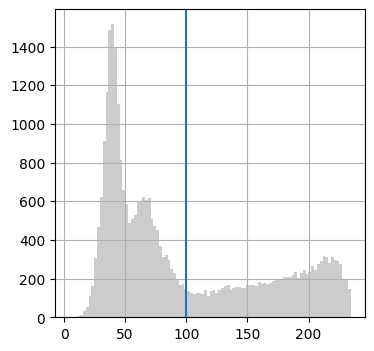

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
(
    sdata["segmentation_features"]
    .obs[f"{marker_channel}_intensity__area_normalized"]
    .loc[~sdata["segmentation_features"].obs["segmentation_outlier"]]
    .hist(bins=100, color="#cccccc", ax=ax)
)

ax.axvline(marker_intensity_cutoff)

In [19]:
sdata["segmentation_features"].obs["positive"] = (
    sdata["segmentation_features"].obs[f"{marker_channel}_intensity__area_normalized"]
    > marker_intensity_cutoff
) & (~sdata["segmentation_features"].obs["segmentation_outlier"])

### Evaluate 

**Critical step**
We can overlay the classification with the tissue image and evaluate it. It is critical that the cell type assignment is robust to effectively enrich for the desired cell type.

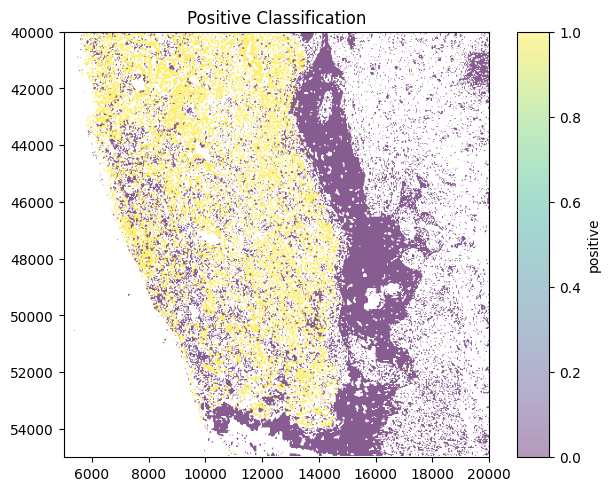

In [20]:
(
    sdata
    # .pl.render_images("image")
    .pl.render_labels("segmentation_mask", color="positive").pl.show(
        title="Positive Classification"
    )
)

## Shape Export

### Generate shape vectors

As described above, the shape export relies on vectorized shapes. This step is automatically done in `harpy`. If other segmentation packages are used that only generate cell segmentation masks (raster data), this step can be used to vectorize the masks and generate contours that can be readily used for shape-export. 

In [21]:
# sdata["segmentation_boundaries"] = sd.to_polygons(sdata["segmentation_mask"])

### Select marker-positive cells

Here, we select the marker-positive cells for shape-export 

In [22]:
positive_cell_ids = (
    sdata["segmentation_features"]
    .obs.loc[sdata["segmentation_features"].obs["positive"], "cell_ID"]
    .to_numpy()
)

In [23]:
positive_shapes = sdata["segmentation_boundaries"].loc[positive_cell_ids]

### Process shapes

#### Simplify

The original shapes as they are returned after segmentation are typically overspecified and contain too many distinct points that cannot be resolved by the LMD. By simplifying the shapes with the Ramer-Douglas-Peuker algorithm (`geopandas.GeoSeries.simplify`), we reduce the number of points in the shapes and size of the generated xml file. 

In [24]:
shape_simplification_tolerance = 1

In [25]:
positive_shapes_simplified = positive_shapes.copy()
positive_shapes_simplified.geometry = positive_shapes_simplified.geometry.simplify(
    tolerance=shape_simplification_tolerance
)

#### Buffer

We can buffer the cell shapes to retain cell integrity during cutting.

In [26]:
buffer_distance = 0.2  # micrometer

In [27]:
if buffer_distance is not None:
    positive_shapes_simplified_buffered = positive_shapes_simplified.copy()
    positive_shapes_simplified_buffered.geometry = (
        positive_shapes_simplified_buffered.geometry.buffer(
            # Convert micrometers to pixel coordinates
            # buffer distance [um] / image resolution [um / pixel]
            distance=buffer_distance / IMAGE_RESOLUTION
        )
    )

### Select shapes for dissection
Typically, it is desired to sample a specific cell area during laser microdissetion. 
Different strategies can be used to obtain the desired number of cells, e.g. 

- Randomly sampling cells until the target area is reached
- Subset cells to specific areas, e.g. histologically distinct areas.

Here, we randomly sample cells from the population of SOX10-positive cells, until the target area is reached (see `src/utils`). Note that we exclude directly adjacent cells from the dissection to ensure cutting success. 

In [28]:
export_well = "B2"  # First row/column cannot be reached by the LMD
target_area = 40_000  # mu2
exclusion_distance = 1  # mu

In [29]:
# In rare cases, harpy will generate multipolygons from the segmented cells, we simplify the multipolygons to polygons
positive_shapes.geometry = positive_shapes.geometry.apply(
    lambda geom: largest_polygon_from_multipolygon(geom)
)

# Convert
selected_shapes = random_sample_by_area(
    gdf=positive_shapes,
    target_area=target_area / IMAGE_RESOLUTION**2,
    exclusion_distance=exclusion_distance / IMAGE_RESOLUTION,
)

selected_shapes["well"] = export_well

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_15374/4253977919.py:69: UserWarning: Select 1 for geom
  warnings.warn(f"Select {idx_max} for geom")
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_15374/4253977919.py:69: UserWarning: Select 0 for geom
  warnings.warn(f"Select {idx_max} for geom")
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_15374/4253977919.py:69: UserWarning: Select 2 for geom
  warnings.warn(f"Select {idx_max} for geom")
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_15374/4253977919.py:69: UserWarning: Select 3 for geom
  warnings.warn(f"Select {idx_max} for geom")
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_15374/4253977919.py:69: UserWarning: Select 4 for geom
  warnings.warn(f"Select {idx_max} for geom")


### Select calibration points


**Critical step**

The selection of calibration points is critical and should be done carefully based on clearly identifyable landmarks or reference crosses. Here, we use an interactive napari session to select 3 calibration points and store them in the spatialdata layer `calibration_points`.

In [32]:
session = Interactive(sdata)
session.run()
# Make sure to press Shift + E to select the layer

2026-07-21 09:44:01.155 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


/Users/lucas-diedrich/mamba/envs/npdvp/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
2026-07-21 09:44:06.694 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-07-21 09:44:06.695 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-07-21 09:44:10.303 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-07-21 09:44:10.307 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.


INFO: Deselected all points in this slice, use ⌘A to select/deselect all points on the layer. (0 selected)


2026-07-21 09:45:07.437 | WARNING  | napari_spatialdata._viewer:_write_element_to_disk:177 - Annotations only added in memory, please manually save to disk.


INFO: Layer(s) inherited info from image
INFO: Layer saved


In [ ]:
calibration_points = sdata["calibration_points"].compute().to_numpy()

# calibration_points = np.array(
#     [
#         [7533.6122947, 42065.03784134],
#         [9260.73534717, 51894.6260392],
#         [13982.91242184, 43171.78333112],
#     ]
# )

### Save shapes with py-lmd

We use py-LMD to write the shapes to a valid xml file. 

In [36]:
collection = pylmd.Collection(
    calibration_points=calibration_points,
    # Make sure that shapes + calibration_points remain unchanged when creating the collection (identity transform)
    orientation_transform=np.eye(2),
    scale=1,
)


# Load shapes from geopandas.GeoDataFrame and export to xml
collection.load_geopandas(selected_shapes, well_column="well")
collection.save(results_path / "shapes.xml")

[ 7533.6122947  42065.03784134]
[ 9260.73534717 51894.6260392 ]
[13982.91242184 43171.78333112]


## Environment

In [37]:
from session_info2 import session_info

session_info(dependencies=True)

Package,Version
spatialdata,0.7.2
geopandas,1.1.3
harpy-analysis,0.3.6
py-lmd,1.5.0
matplotlib,3.10.8
numpy,2.1.0
pandas,2.3.3
seaborn,0.13.2
shapely,2.1.2
spatialdata-plot,0.3.3
